# Experiment 12: Comprehensive Comparison
This notebook compares the tagging performance (vs human annotators) of all model variations tested in Exp 10 and Exp 11:
- Exp10a Baseline (initial prompt)
- Exp10b Enriched (initial prompt + mental model context)
- Exp11 Baseline (v2 Curriculum-Aware prompt)
- Exp11 Enriched (v2 Curriculum-Aware prompt + mental model context)

We will compare these 4 methods against the identical subset of human overlap (Human A and Human B) to conclude which pipeline performs best.

In [1]:
import json
import os
from pathlib import Path
from typing import Dict, List, Set, Tuple

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if not (ROOT / "lib").exists() and (ROOT.parent / "lib").exists():
    ROOT = ROOT.parent
    os.chdir(ROOT)

print(f"Working directory: {os.getcwd()}")

Working directory: /mnt/d/Projects/kintsugi


In [2]:
# Setup: Exact KC Tags from previous scripts
EXACT_KC_TAGS = [
    'If/Else', 'NestedIf', 'While', 'For', 'NestedFor',
    'Math+-*/', 'Math%', 'LogicAndNotOr', 'LogicCompareNum', 'LogicBoolean',
    'StringFormat', 'StringConcat', 'StringIndex', 'StringLen',
    'StringEqual', 'CharEqual', 'ArrayIndex', 'DefFunction'
]

def load_annotations(filepath: str) -> Tuple[str, Dict[str, Set[str]]]:
    path = Path(filepath)
    if not path.exists():
        print(f"Warning: File not found {filepath}")
        return path.stem, {}
    with path.open("r", encoding="utf-8") as f:
        data = json.load(f)
    rater_name = data.get("rater", path.stem)
    student_id = data.get("student_id", data.get("studentId", "unknown"))
    parsed: Dict[str, Set[str]] = {}
    
    for pid, val in data.get("annotations", {}).items():
        comp_pid = f"{student_id}_{pid}"
        if isinstance(val, dict) and "gaps" in val:
            gaps = val.get("gaps")
            parsed[comp_pid] = set(gaps) if isinstance(gaps, list) else set()
        elif isinstance(val, list):
            parsed[comp_pid] = set(val)
        else:
            parsed[comp_pid] = set()
            
        # Also clean empty strings and non-exact tags, if present in messy outputs
        parsed[comp_pid] = {t for t in parsed[comp_pid] if t in EXACT_KC_TAGS}

    return rater_name, parsed

def merge_rater_files(filepaths: List[str], label: str) -> Tuple[str, Dict[str, Set[str]]]:
    merged = {}
    for fp in filepaths:
        _, anns = load_annotations(fp)
        for comp_pid, kcs in anns.items():
            if comp_pid in merged:
                merged[comp_pid].update(kcs)
            else:
                merged[comp_pid] = set(kcs)
    return label, merged

In [3]:
# File paths for all 6 entities
HUMAN_A_FILES = [
    "dataset/Rater_KC_Tags/kc_annotations_Pranay Ghuge_10155_1774736175604.json",
    "dataset/Rater_KC_Tags/kc_annotations_Pranay Ghuge_14475_1775593592812.json",
    "dataset/Rater_KC_Tags/kc_annotations_Pranay Ghuge_14476_1775593175294.json",
]
HUMAN_B_FILES = [
    "dataset/Rater_KC_Tags/kc_annotations_Arundhati Das_10155_1774820622134.json",
    "dataset/Rater_KC_Tags/kc_annotations_Arundhati Das_14475_1775593132134.json",
    "dataset/Rater_KC_Tags/kc_annotations_Arundhati Das_14476_1775691915454.json",
]

EXP10A_BASE_FILES = [
    "results/human_validation/llm_baseline_annotations_10155.json",
    "results/human_validation/llm_baseline_annotations_14475.json",
    "results/human_validation/llm_baseline_annotations_14476.json"
]

EXP10B_ENR_FILES = [
    "results/human_validation/llm_annotations_10155.json",
    "results/human_validation/llm_annotations_14475.json",
    "results/human_validation/llm_annotations_14476.json"
]

EXP11A_BASE_FILES = [
    "results/human_validation/llm_baseline_annotations_v2_10155.json",
    "results/human_validation/llm_baseline_annotations_v2_14475.json",
    "results/human_validation/llm_baseline_annotations_v2_14476.json"
]

EXP11B_ENR_FILES = [
    "results/human_validation/llm_enriched_annotations_v2_10155.json",
    "results/human_validation/llm_enriched_annotations_v2_14475.json",
    "results/human_validation/llm_enriched_annotations_v2_14476.json"
]

# Load dictionaries
_, anns_ha = merge_rater_files(HUMAN_A_FILES, "Human A")
_, anns_hb = merge_rater_files(HUMAN_B_FILES, "Human B")

_, anns_10a = merge_rater_files(EXP10A_BASE_FILES, "Exp10a Baseline")
_, anns_10b = merge_rater_files(EXP10B_ENR_FILES, "Exp10b Enriched")
_, anns_11a = merge_rater_files(EXP11A_BASE_FILES, "Exp11a Baseline V2")
_, anns_11b = merge_rater_files(EXP11B_ENR_FILES, "Exp11b Enriched V2")

# Get Intersection of ALL
sets = [set(anns_ha.keys()), set(anns_hb.keys()), set(anns_10a.keys()), set(anns_10b.keys()), set(anns_11a.keys()), set(anns_11b.keys())]
common_pids = sorted(sets[0].intersection(*sets))
print(f"Total overlapping problems evaluated across *all* files: {len(common_pids)}")

Total overlapping problems evaluated across *all* files: 146


In [4]:
from sklearn.metrics import cohen_kappa_score, f1_score, precision_score, recall_score

def compute_metrics(name_a: str, anns_a: Dict[str, Set[str]], name_b: str, anns_b: Dict[str, Set[str]], common_pids: List[str]):
    y_a, y_b = [], []
    for pid in common_pids:
        gaps_a, gaps_b = anns_a.get(pid, set()), anns_b.get(pid, set())
        for kc in EXACT_KC_TAGS:
            y_a.append(1 if kc in gaps_a else 0)
            y_b.append(1 if kc in gaps_b else 0)

    y_a, y_b = np.array(y_a), np.array(y_b)
    n = len(y_a)
    if n == 0: return {"name": f"{name_a} vs {name_b}", "kappa": 0.0, "f1": 0.0, "precision": 0.0, "recall": 0.0}

    kappa = cohen_kappa_score(y_a, y_b)
    f1 = f1_score(y_a, y_b, zero_division=0)
    precision = precision_score(y_a, y_b, zero_division=0)
    recall = recall_score(y_a, y_b, zero_division=0)

    return {"name": f"{name_a} vs {name_b}", "kappa": kappa, "f1": f1, "precision": precision, "recall": recall}

def evaluate_model(model_name: str, model_anns: dict):
    res_a = compute_metrics("Human A", anns_ha, model_name, model_anns, common_pids)
    res_b = compute_metrics("Human B", anns_hb, model_name, model_anns, common_pids)
    
    avg_kappa = (res_a['kappa'] + res_b['kappa']) / 2
    avg_f1 = (res_a['f1'] + res_b['f1']) / 2
    avg_prec = (res_a['precision'] + res_b['precision']) / 2
    avg_rec = (res_a['recall'] + res_b['recall']) / 2
    
    return {
        "model": model_name,
        "kappa": avg_kappa,
        "f1": avg_f1,
        "precision": avg_prec,
        "recall": avg_rec
    }

# Compute performance across all models
eval_10a = evaluate_model("Exp10a Baseline", anns_10a)
eval_10b = evaluate_model("Exp10b Enriched", anns_10b)
eval_11a = evaluate_model("Exp11 Baseline V2", anns_11a)
eval_11b = evaluate_model("Exp11 Enriched V2", anns_11b)

res_h_h = compute_metrics("Human A", anns_ha, "Human B", anns_hb, common_pids)

print("\n" + "=" * 90)
print(f"{'Comparison':<25} {'Average Kappa':>15} {'Average F1':>10} {'Average Prec':>15} {'Average Rec':>15}")
print("-" * 90)
print(f"{'Human A vs Human B':<25} {res_h_h['kappa']:>15.3f} {res_h_h['f1']:>10.3f} {res_h_h['precision']:>15.3f} {res_h_h['recall']:>15.3f}")
print("-" * 90)

results = [eval_10a, eval_10b, eval_11a, eval_11b]
for r in results:
    print(f"{r['model']:<25} {r['kappa']:>15.3f} {r['f1']:>10.3f} {r['precision']:>15.3f} {r['recall']:>15.3f}")
print("=" * 90)


Comparison                  Average Kappa Average F1    Average Prec     Average Rec
------------------------------------------------------------------------------------------
Human A vs Human B                  0.421      0.459           0.398           0.543
------------------------------------------------------------------------------------------
Exp10a Baseline                     0.300      0.352           0.317           0.401
Exp10b Enriched                     0.321      0.359           0.425           0.315
Exp11 Baseline V2                   0.371      0.412           0.428           0.401
Exp11 Enriched V2                   0.354      0.396           0.402           0.396


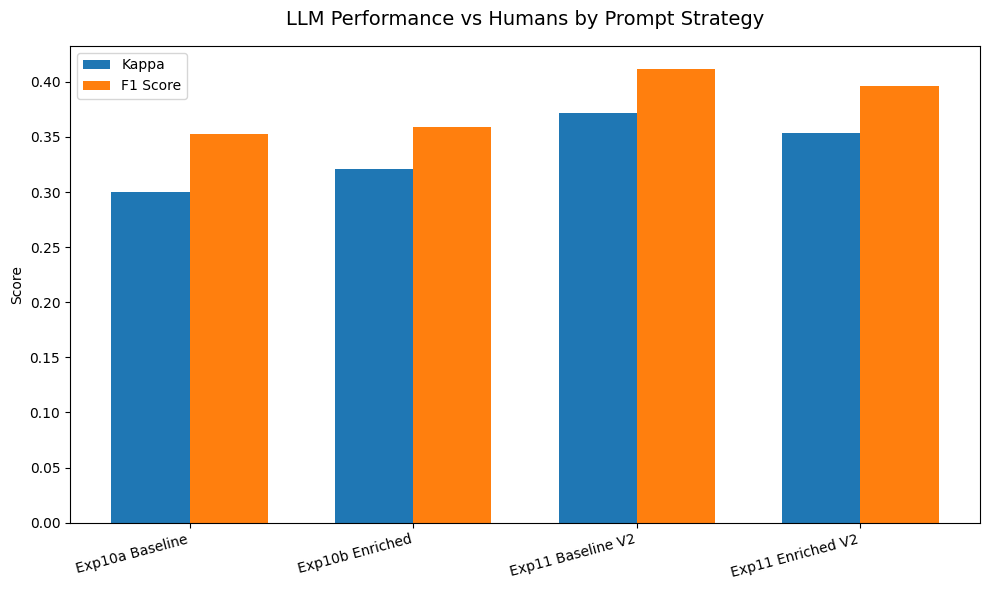


Best Overall Model (by F1): Exp11 Baseline V2 with F1=0.412 and Kappa=0.371


In [5]:
df_results = pd.DataFrame(results)

# Create a grouped bar chart
plt.figure(figsize=(10, 6))

x = np.arange(len(df_results))
width = 0.35

plt.bar(x - width/2, df_results['kappa'], width, label='Kappa')
plt.bar(x + width/2, df_results['f1'], width, label='F1 Score')

plt.ylabel('Score')
plt.title('LLM Performance vs Humans by Prompt Strategy', fontsize=14, pad=15)
plt.xticks(x, df_results['model'], rotation=15, ha='right')
plt.legend()
plt.tight_layout()

# Save the plot
plt.savefig("results/visualizations/all_models_comparison.png", dpi=300)
plt.show()

# Find the best model based on F1 (or Kappa)
best_f1_model = df_results.loc[df_results['f1'].idxmax()]
print(f"\nBest Overall Model (by F1): {best_f1_model['model']} with F1={best_f1_model['f1']:.3f} and Kappa={best_f1_model['kappa']:.3f}")